In [1]:
import sys
sys.path.append("/data/user/gsommani/alertstack3.12/lib/python3.12/site-packages/")
sys.path.append("/data/user/gsommani/New_Updated_Alerts_Stacking/")
from astropy.io import fits
import healpy as hp
import matplotlib.pyplot as plt
import numpy as np
import os
from scipy import stats
from scipy.stats import distributions, uniform
from astropy.coordinates import angular_separation
from alertstack.scramble_catalogues.agn_radio_catalogue import (
    AstrogeoAGNCatalogue, AverageFluxWeightHypothesis
)
from alertstack.fixed_catalogues.icecube_neutrino_alerts import (
    HealpixNeutrinoAlertCatalogue
)

In [2]:
def mykstest_lats(decs, bkg, min_dec):

    min_dec = min_dec * np.pi / 180.
    
    npix = len(bkg)
    nside = hp.npix2nside(npix)
    colats, lons = hp.pix2ang(nside, np.arange(npix))
    lats = np.pi / 2. - colats
    possible_lats = np.sort(np.array(list(set(lats))))
    prob_per_lat = np.cumsum(np.array(
        [np.sum(bkg[lats==lat]) for lat in possible_lats]
    ))
    s = np.linspace(1/len(decs), 1, len(decs))
    cumul_data = np.array(
        [prob_per_lat[np.sum(
            possible_lats < dec
        ) - 1] for dec in np.sort(decs)]
    )
    decs = np.sort(decs)
    cumul_data_uniform = (np.sin(decs) - np.sin(min_dec)) / (1 - np.sin(min_dec))
    #print(s, cumul_data , s-cumul_data)
    diffs = np.abs(s-cumul_data)
    diffs_uniform = np.abs(s-cumul_data_uniform)
    ts = np.max(diffs)
    ts_uniform = np.max(diffs_uniform)
    pval = distributions.ksone.sf(ts, len(decs))
    pval_uniform = distributions.ksone.sf(ts_uniform, len(decs))
    print(f"ts: {ts}, ts_uniform: {ts_uniform}")
    print(f"pval: {pval}, pval_uniform: {pval_uniform}")
    return pval, pval_uniform

def mykstest_lons(ras, bkg):
    
    npix = len(bkg)
    nside = hp.npix2nside(npix)
    colats, lons = hp.pix2ang(nside, np.arange(npix))
    possible_lons = np.sort(np.array(list(set(lons))))
    prob_per_lon = np.cumsum(np.array(
        [np.sum(bkg[lons==lon]) for lon in possible_lons]
    ))
    s = np.linspace(1/len(ras), 1, len(ras))
    cumul_data = np.array(
        [prob_per_lon[np.sum(
            possible_lons < ra
        ) - 1] for ra in np.sort(ras)]
    )
    ras = np.sort(ras)
    cumul_data_uniform = ras / ( 2 * np.pi )
    diffs = np.abs(s-cumul_data)
    diffs_uniform = np.abs(s-cumul_data_uniform)
    ts = np.max(diffs)
    ts_uniform = np.max(diffs_uniform)
    pval = distributions.ksone.sf(ts, len(ras))
    pval_uniform = distributions.ksone.sf(ts_uniform, len(ras))
    print(f"ts: {ts}, ts_uniform: {ts_uniform}")
    print(f"pval: {pval}, pval_uniform: {pval_uniform}")
    return pval, pval_uniform

def mykstest_lon_lat(cat, bkg, min_dec, print_pvals=True):
    pval_lon = mykstest_lons(cat["ra_rad"], bkg)
    pval_lat = mykstest_lats(cat["dec_rad"], bkg, min_dec)
    return

In [3]:
cat_obj = AstrogeoAGNCatalogue()
cat = cat_obj.data
mykstest_lon_lat(cat, cat_obj.bkg_distribution, cat_obj.min_declination)

ts: 0.005630955879689092, ts_uniform: 0.013316467096443518
pval: 0.8039040668714768, pval_uniform: 0.2986002595668995
ts: 0.00747135716047298, ts_uniform: 0.02258916078597739
pval: 0.6820537823539796, pval_uniform: 0.031188240443566148


(-1.0, 1.0)

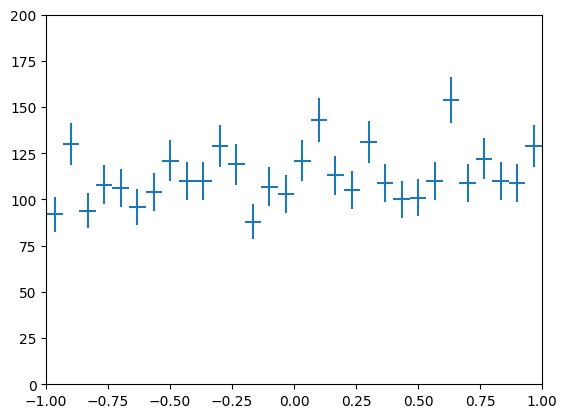

In [4]:
counts, bins = np.histogram(np.sin(cat["dec_rad"]), bins=30)

plt.errorbar(
    (bins[:-1]+bins[1:])/2.,
    counts,
    np.sqrt(counts),
    (bins[1:]-bins[:-1])/2.,
    linestyle=""
)

plt.ylim(0, 200)
plt.xlim(-1, 1)

(0.0, 360.0)

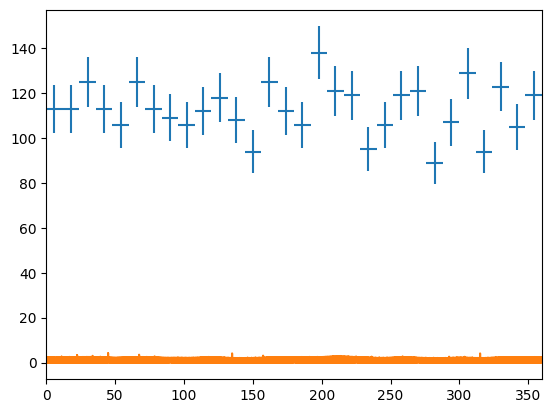

In [5]:
counts, bins = np.histogram(cat["ra_deg"], bins=30)
plt.errorbar(
    (bins[:-1]+bins[1:])/2.,
    counts,
    np.sqrt(counts),
    (bins[1:]-bins[:-1])/2.,
    linestyle=""
)

npix = len(cat_obj.bkg_distribution)
nside = hp.npix2nside(npix)
colats, lons = hp.pix2ang(nside, np.arange(npix))
possible_lons = np.sort(np.array(list(set(lons))))
prob_per_lon = np.array(
    [np.sum(cat_obj.bkg_distribution[lons==lon]) for lon in possible_lons]
)
plt.plot(possible_lons*180./np.pi, prob_per_lon*len(cat_obj.data))

#plt.ylim(0, 200)
plt.xlim(0, 360)

(-1.0, 1.0)

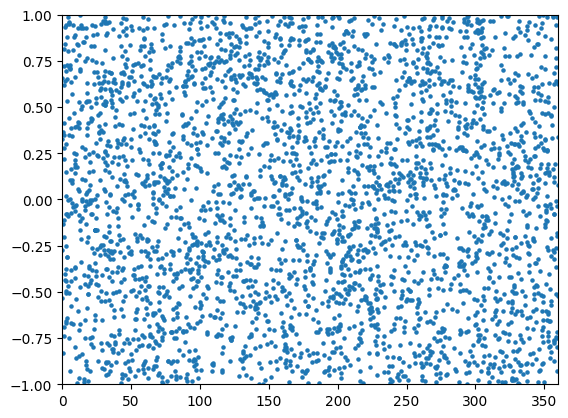

In [6]:
plt.scatter(cat["ra_deg"], np.sin(cat["dec_rad"]), s=5)
plt.xlim(0,360)
plt.ylim(-1,1)

In [7]:
cat_obj.generate_bkg_distribution_allsky(cat, 16)

array([5.57507855e-06, 5.57742610e-06, 5.58117348e-06, ...,
       4.57661906e-06, 4.58535417e-06, 4.60126080e-06], shape=(196608,))

Text(0, 0.5, 'Dec. [deg]')

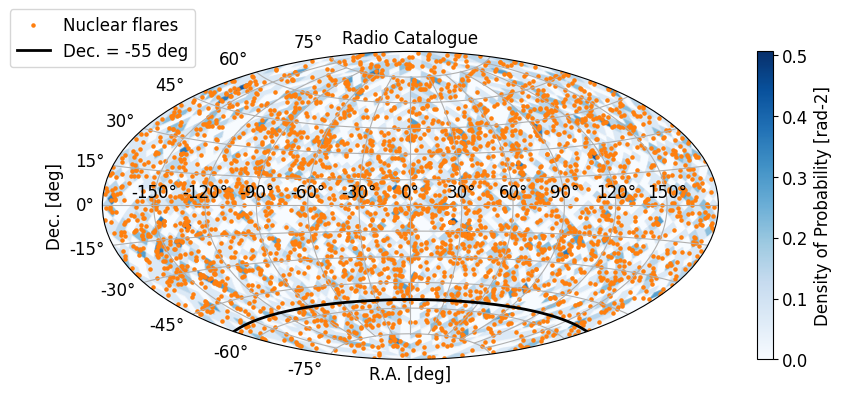

In [8]:
theta = np.pi/2. - cat["dec_deg"].to_numpy()*np.pi/180.
phi = cat["ra_deg"].to_numpy()*np.pi/180.

nside = 16
hd_nside = 256
bins_per_source = hp.ang2pix(nside, theta, phi)
bins = np.arange(hp.nside2npix(nside)+1)
counts_per_bin, _ = np.histogram(bins_per_source, bins=bins)
bins_probs = counts_per_bin/np.sum(counts_per_bin)
bins_probs = bins_probs / hp.nside2pixarea(nside)

bins_probs = hp.ud_grade(bins_probs, hd_nside)
bins_cothetas, bins_phis = hp.pix2ang(hd_nside, np.arange(hp.nside2npix(hd_nside)))
bins_thetas = np.pi / 2. - bins_cothetas

phis_mollweide = np.empty(len(bins_phis))
phis_mollweide[bins_phis<=np.pi] = bins_phis[bins_phis<=np.pi]
phis_mollweide[bins_phis>np.pi] = bins_phis[bins_phis>np.pi] - 2*np.pi

plt.figure(figsize=(10,4))
ax = plt.subplot(111, projection='aitoff')

im = plt.scatter(phis_mollweide, bins_thetas, c=bins_probs, cmap="Blues", s=0.01)


cat_obj = AstrogeoAGNCatalogue()
cat = cat_obj.parse_data()
ras_mollweide = np.empty(len(cat))
ras_mollweide[cat["ra_deg"]<=180.] = cat["ra_deg"][cat["ra_deg"]<=180.]
ras_mollweide[cat["ra_deg"]>180.] = cat["ra_deg"][cat["ra_deg"]>180.] - 360.

plt.scatter(
    ras_mollweide*np.pi/180.,
    cat["dec_deg"]*np.pi/180.,
    s=5,
    label="Nuclear flares",
    c="tab:orange",
    #c=weighter.weight_catalogue(acflares, nu_at=0., ignore_times=True),
    #c=weightstrength*weightflux,
    #norm="log",
    #cmap="plasma"
)

ras_bord = np.linspace(-np.pi, np.pi, 100)
des_bord = np.empty(len(ras_bord))
des_bord.fill(-55.*np.pi/180.)
plt.plot(ras_bord, des_bord, color="black", label="Dec. = -55 deg", linewidth=2)

plt.legend(loc=(-0.15, 0.95), fontsize='large')
cb = plt.gcf().colorbar(im)
cb.ax.tick_params(labelsize="large")
cb.set_label(label="Density of Probability [rad-2]", fontsize="large")

plt.grid()

plt.xticks(fontsize="large")
plt.yticks(fontsize="large")

plt.title("Radio Catalogue")
plt.xlabel("R.A. [deg]", fontsize="large")
plt.ylabel("Dec. [deg]", fontsize="large")

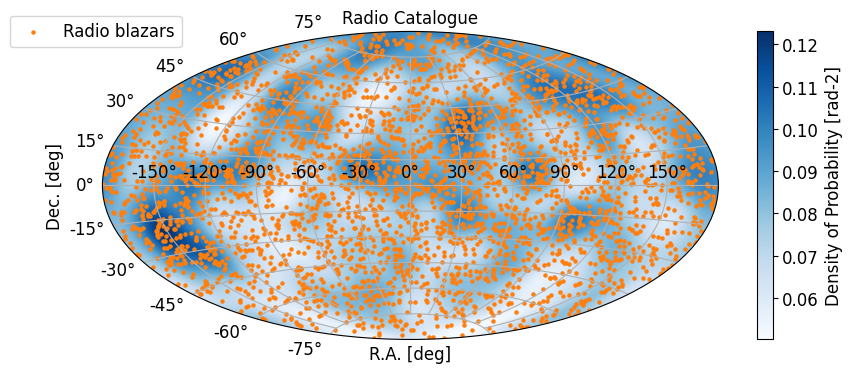

In [10]:
bins_probs = hp.ud_grade(cat_obj.bkg_distribution, hd_nside)
bins_probs = bins_probs / hp.nside2pixarea(128)
bins_cothetas, bins_phis = hp.pix2ang(hd_nside, np.arange(hp.nside2npix(hd_nside)))
bins_thetas = np.pi / 2. - bins_cothetas

bins_probs = hp.ud_grade(bins_probs, hd_nside)
bins_cothetas, bins_phis = hp.pix2ang(hd_nside, np.arange(hp.nside2npix(hd_nside)))
bins_thetas = np.pi / 2. - bins_cothetas

phis_mollweide = np.empty(len(bins_phis))
phis_mollweide[bins_phis<=np.pi] = bins_phis[bins_phis<=np.pi]
phis_mollweide[bins_phis>np.pi] = bins_phis[bins_phis>np.pi] - 2*np.pi

plt.figure(figsize=(10,4))
ax = plt.subplot(111, projection='aitoff')

im = plt.scatter(phis_mollweide, bins_thetas, c=bins_probs, cmap="Blues", s=0.01)


cat_obj = AstrogeoAGNCatalogue()
cat = cat_obj.parse_data()
ras_mollweide = np.empty(len(cat))
ras_mollweide[cat["ra_deg"]<=180.] = cat["ra_deg"][cat["ra_deg"]<=180.]
ras_mollweide[cat["ra_deg"]>180.] = cat["ra_deg"][cat["ra_deg"]>180.] - 360.

plt.scatter(
    ras_mollweide*np.pi/180.,
    cat["dec_deg"]*np.pi/180.,
    s=5,
    label="Radio blazars",
    c="tab:orange",
    #c=weighter.weight_catalogue(acflares, nu_at=0., ignore_times=True),
    #c=weightstrength*weightflux,
    #norm="log",
    #cmap="plasma"
)

# ras_bord = np.linspace(-np.pi, np.pi, 100)
# des_bord = np.empty(len(ras_bord))
# des_bord.fill(-55.*np.pi/180.)
# plt.plot(ras_bord, des_bord, color="black", label="Dec. = -55 deg", linewidth=2)

plt.legend(loc=(-0.15, 0.95), fontsize='large')
cb = plt.gcf().colorbar(im)
cb.ax.tick_params(labelsize="large")
cb.set_label(label="Density of Probability [rad-2]", fontsize="large")

plt.grid()

plt.xticks(fontsize="large")
plt.yticks(fontsize="large")

plt.title("Radio Catalogue")
plt.xlabel("R.A. [deg]", fontsize="large")
plt.ylabel("Dec. [deg]", fontsize="large")

plt.savefig("Radio_bkg_pdf", bbox_inches="tight", dpi=200)

Text(0, 0.5, 'Dec. [deg]')

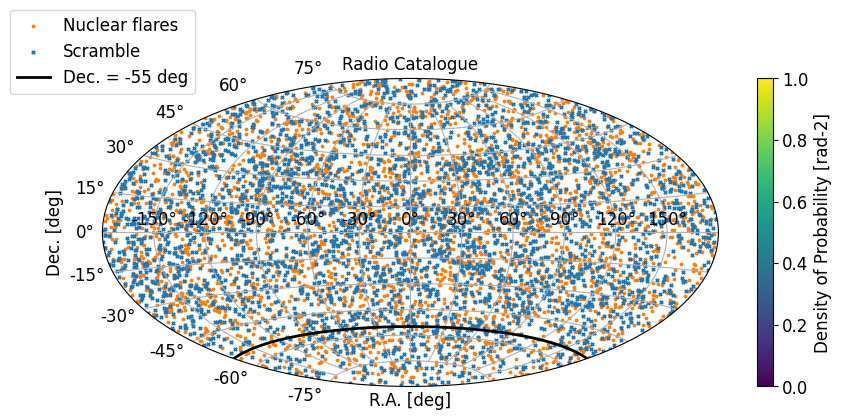

In [10]:
scramble = cat_obj.scramble()
bins_thetas = scramble["dec_rad"]
bins_phis = scramble["ra_rad"]

phis_mollweide = np.empty(len(bins_phis))
phis_mollweide[bins_phis<=np.pi] = bins_phis[bins_phis<=np.pi]
phis_mollweide[bins_phis>np.pi] = bins_phis[bins_phis>np.pi] - 2*np.pi

plt.figure(figsize=(10,4))
ax = plt.subplot(111, projection='aitoff')


cat_obj = AstrogeoAGNCatalogue()
cat = cat_obj.parse_data()
ras_mollweide = np.empty(len(cat))
ras_mollweide[cat["ra_deg"]<=180.] = cat["ra_deg"][cat["ra_deg"]<=180.]
ras_mollweide[cat["ra_deg"]>180.] = cat["ra_deg"][cat["ra_deg"]>180.] - 360.

plt.scatter(
    ras_mollweide*np.pi/180.,
    cat["dec_deg"]*np.pi/180.,
    s=3,
    label="Nuclear flares",
    c="tab:orange",
    #c=weighter.weight_catalogue(acflares, nu_at=0., ignore_times=True),
    #c=weightstrength*weightflux,
    #norm="log",
    #cmap="plasma"
)

im = plt.scatter(
    phis_mollweide,
    bins_thetas,
    c="tab:blue",
    s=5,
    label="Scramble",
    marker="x"
)

ras_bord = np.linspace(-np.pi, np.pi, 100)
des_bord = np.empty(len(ras_bord))
des_bord.fill(-55.*np.pi/180.)
plt.plot(ras_bord, des_bord, color="black", label="Dec. = -55 deg", linewidth=2)

plt.legend(loc=(-0.15, 0.95), fontsize='large')
cb = plt.gcf().colorbar(im)
cb.ax.tick_params(labelsize="large")
cb.set_label(label="Density of Probability [rad-2]", fontsize="large")

plt.grid()

plt.xticks(fontsize="large")
plt.yticks(fontsize="large")

plt.title("Radio Catalogue")
plt.xlabel("R.A. [deg]", fontsize="large")
plt.ylabel("Dec. [deg]", fontsize="large")

Text(0, 0.5, 'Dec. [deg]')

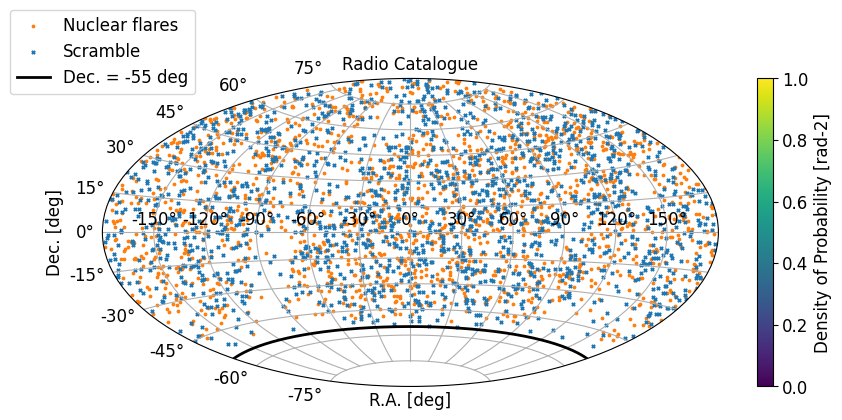

In [13]:
scramble = cat_obj.scramble()
bins_thetas = scramble["dec_rad"]
bins_phis = scramble["ra_rad"]

phis_mollweide = np.empty(len(bins_phis))
phis_mollweide[bins_phis<=np.pi] = bins_phis[bins_phis<=np.pi]
phis_mollweide[bins_phis>np.pi] = bins_phis[bins_phis>np.pi] - 2*np.pi

plt.figure(figsize=(10,4))
ax = plt.subplot(111, projection='aitoff')


cat_obj = AstrogeoAGNCatalogue()
cat = cat_obj.parse_data()
ras_mollweide = np.empty(len(cat))
ras_mollweide[cat["ra_deg"]<=180.] = cat["ra_deg"][cat["ra_deg"]<=180.]
ras_mollweide[cat["ra_deg"]>180.] = cat["ra_deg"][cat["ra_deg"]>180.] - 360.

plt.scatter(
    ras_mollweide*np.pi/180.,
    cat["dec_deg"]*np.pi/180.,
    s=3,
    label="Nuclear flares",
    c="tab:orange",
    #c=weighter.weight_catalogue(acflares, nu_at=0., ignore_times=True),
    #c=weightstrength*weightflux,
    #norm="log",
    #cmap="plasma"
)

im = plt.scatter(
    phis_mollweide,
    bins_thetas,
    c="tab:blue",
    s=5,
    label="Scramble",
    marker="x"
)

ras_bord = np.linspace(-np.pi, np.pi, 100)
des_bord = np.empty(len(ras_bord))
des_bord.fill(-55.*np.pi/180.)
plt.plot(ras_bord, des_bord, color="black", label="Dec. = -55 deg", linewidth=2)

plt.legend(loc=(-0.15, 0.95), fontsize='large')
cb = plt.gcf().colorbar(im)
cb.ax.tick_params(labelsize="large")
cb.set_label(label="Density of Probability [rad-2]", fontsize="large")

plt.grid()

plt.xticks(fontsize="large")
plt.yticks(fontsize="large")

plt.title("Radio Catalogue")
plt.xlabel("R.A. [deg]", fontsize="large")
plt.ylabel("Dec. [deg]", fontsize="large")

Text(0, 0.5, 'Dec. [deg]')

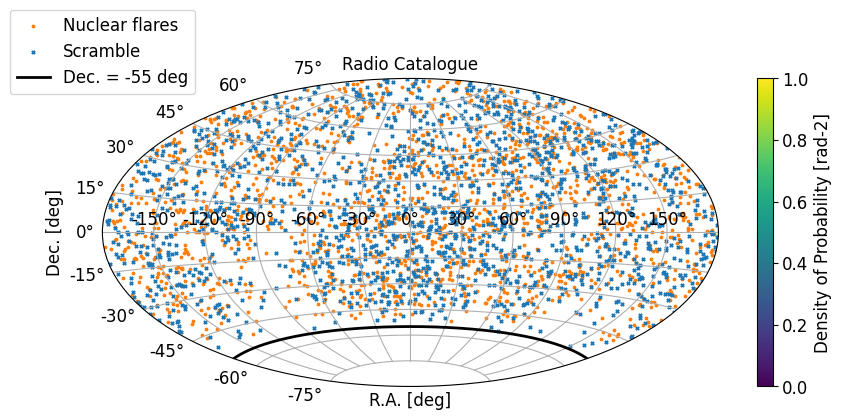

In [14]:
scramble = cat_obj.scramble()
bins_thetas = scramble["dec_rad"]
bins_phis = scramble["ra_rad"]

phis_mollweide = np.empty(len(bins_phis))
phis_mollweide[bins_phis<=np.pi] = bins_phis[bins_phis<=np.pi]
phis_mollweide[bins_phis>np.pi] = bins_phis[bins_phis>np.pi] - 2*np.pi

plt.figure(figsize=(10,4))
ax = plt.subplot(111, projection='aitoff')


cat_obj = AstrogeoAGNCatalogue()
cat = cat_obj.parse_data()
ras_mollweide = np.empty(len(cat))
ras_mollweide[cat["ra_deg"]<=180.] = cat["ra_deg"][cat["ra_deg"]<=180.]
ras_mollweide[cat["ra_deg"]>180.] = cat["ra_deg"][cat["ra_deg"]>180.] - 360.

plt.scatter(
    ras_mollweide*np.pi/180.,
    cat["dec_deg"]*np.pi/180.,
    s=3,
    label="Nuclear flares",
    c="tab:orange",
    #c=weighter.weight_catalogue(acflares, nu_at=0., ignore_times=True),
    #c=weightstrength*weightflux,
    #norm="log",
    #cmap="plasma"
)

im = plt.scatter(
    phis_mollweide,
    bins_thetas,
    c="tab:blue",
    s=5,
    label="Scramble",
    marker="x"
)

ras_bord = np.linspace(-np.pi, np.pi, 100)
des_bord = np.empty(len(ras_bord))
des_bord.fill(-55.*np.pi/180.)
plt.plot(ras_bord, des_bord, color="black", label="Dec. = -55 deg", linewidth=2)

plt.legend(loc=(-0.15, 0.95), fontsize='large')
cb = plt.gcf().colorbar(im)
cb.ax.tick_params(labelsize="large")
cb.set_label(label="Density of Probability [rad-2]", fontsize="large")

plt.grid()

plt.xticks(fontsize="large")
plt.yticks(fontsize="large")

plt.title("Radio Catalogue")
plt.xlabel("R.A. [deg]", fontsize="large")
plt.ylabel("Dec. [deg]", fontsize="large")

In [12]:
def get_ang_dists(rnd_lat, rnd_lon):
    ang_seps = list()
    for i, (lon, lat) in enumerate(zip(rnd_lon, rnd_lat)):
        rnd_lon_rad_reduced = np.delete(rnd_lon, i)
        rnd_lat_rad_reduced = np.delete(rnd_lat, i)
        ang_sep = np.rad2deg(
            angular_separation(
                lat,
                lon,
                rnd_lat_rad_reduced,
                rnd_lon_rad_reduced,
            )
        )
        ang_seps.append(ang_sep)
    ang_seps = np.concatenate(ang_seps)
    return ang_seps

name_cat = "table-4LAC-DR2-h.fits"
alertstack_data_dir = "../../alertstack/data/"
with fits.open(os.path.join(alertstack_data_dir, name_cat)) as hdul:
    cat = hdul[1].data
    header = hdul[1].header
cat = np.sort(cat, order="Energy_Flux100")[::-1]

#blazar_class = ["bll", "BLL", "fsrq", "FSRQ", "bcu", "BCU"]
blazar_class = ["bll", "BLL", "fsrq", "FSRQ", "bcu", "BCU"]

mask = np.array([x["CLASS"] in blazar_class for x in cat])
blazars = np.array(cat[mask])

blazars_cuts = []
for i in range(5):
    cut_e = -12. + 0.1*i
    print(f"cut_e: {cut_e}")
    mask_e = np.array([x["Energy_Flux100"]>10**cut_e for x in blazars])
    blazars_cut = np.array(blazars[mask_e])
    blazars_cuts.append(blazars_cut)

mc_ang_seps = list()
for j in range(50):
    print(j)
    rnd_lon = uniform.rvs(
        size=int(len(blazars["GLON"]))
    ) * 360.
    rnd_lat_pos = uniform.rvs(
        size=int(len(blazars["GLAT"])/2.)
    ) * (1. - np.sin(np.deg2rad(10.))) + np.sin(np.deg2rad(10.))
    addition = 0
    if len(blazars["GLAT"])%2 != 0.:
        addition = 1
    rnd_lat_neg = - ( uniform.rvs(
        size=int(len(blazars["GLAT"])/2.  + addition)
    ) * (1. - np.sin(np.deg2rad(10.))) + np.sin(np.deg2rad(10.)))
    rnd_lat = np.append(rnd_lat_pos, rnd_lat_neg)
    
    rnd_lon_rad = np.deg2rad(np.array(rnd_lon))
    rnd_lat_rad = np.asin(np.array(rnd_lat))
    
    ang_seps = get_ang_dists(rnd_lon_rad, rnd_lat_rad)
    vals, quantiles, _ = plt.hist(ang_seps, bins=20, range=(0,180))
    plt.close()
    mc_ang_seps.append(vals)
    xs = (quantiles[:-1] + quantiles[1:])/2.

mc_ang_seps = np.array(mc_ang_seps)
mc_means = np.array([np.mean(mc_ang_seps[:,i]) for i in range(len(mc_ang_seps[0]))])
mc_stds = np.array([np.std(mc_ang_seps[:,i]) for i in range(len(mc_ang_seps[0]))])

cut_e: -12.0
cut_e: -11.9
cut_e: -11.8
cut_e: -11.7
cut_e: -11.6
0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49


Text(0.5, 0, 'Angular distance between blazar pairs [deg]')

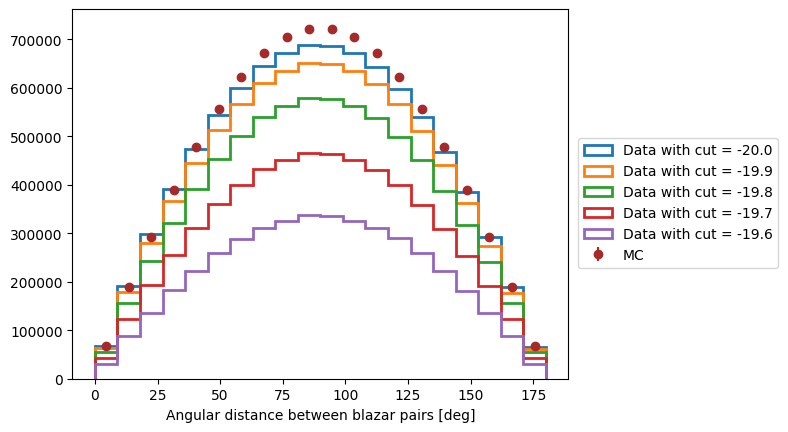

In [10]:
for i, cat in enumerate(blazars_cuts):
    cut = -20.0 + i * 0.1
    ang_seps_real = get_ang_dists(
        np.deg2rad(cat["GLON"]),
        np.deg2rad(cat["GLAT"])
    )
    plt.hist(
        ang_seps_real, bins=20, range=(0,180), histtype='step', linewidth=2,
        label=f"Data with cut = {cut}"
    )
plt.errorbar(
    xs, mc_means, mc_stds, marker='o', linestyle='', color="brown",
    label="MC"
)
plt.legend(loc=(1.02,0.3))
plt.xlabel("Angular distance between blazar pairs [deg]")

In [11]:
def get_ang_dists(rnd_lat, rnd_lon):
    ang_seps = list()
    for i, (lon, lat) in enumerate(zip(rnd_lon, rnd_lat)):
        rnd_lon_rad_reduced = np.delete(rnd_lon, i)
        rnd_lat_rad_reduced = np.delete(rnd_lat, i)
        ang_sep = np.rad2deg(
            angular_separation(
                lat,
                lon,
                rnd_lat_rad_reduced,
                rnd_lon_rad_reduced,
            )
        )
        ang_seps.append(ang_sep)
    ang_seps = np.concatenate(ang_seps)
    return ang_seps

def uniform_2d_test(name_cat="table_4LAC.fits", density=False):
    alertstack_data_dir = "../../alertstack/data/"
    with fits.open(os.path.join(alertstack_data_dir, name_cat)) as hdul:
        cat = hdul[1].data
        header = hdul[1].header
    cat = np.sort(cat, order="Energy_Flux100")[::-1]
    
    #blazar_class = ["bll", "BLL", "fsrq", "FSRQ", "bcu", "BCU"]
    blazar_class = ["bll", "BLL", "fsrq", "FSRQ", "bcu", "BCU"]
    
    mask = np.array([x["CLASS"] in blazar_class for x in cat])
    blazars = np.array(cat[mask])
    
    blazars_cuts = []
    for i in range(5):
        cut_e = -12. + 0.1*i
        print(f"cut_e: {cut_e}")
        mask_e = np.array([x["Energy_Flux100"]>10**cut_e for x in blazars])
        blazars_cut = np.array(blazars[mask_e])
        blazars_cuts.append(blazars_cut)
    
    mc_ang_seps = list()
    mc_ang_seps_plot = list()
    for j in range(50):
        if j%10 == 0: print(j)
        rnd_lon = uniform.rvs(
            size=int(len(blazars["GLON"]))
        ) * 360.
        rnd_lat_pos = uniform.rvs(
            size=int(len(blazars["GLAT"])/2.)
        ) * (1. - np.sin(np.deg2rad(10.))) + np.sin(np.deg2rad(10.))
        addition = 0
        if len(blazars["GLAT"])%2 != 0.:
            addition = 1
        rnd_lat_neg = - ( uniform.rvs(
            size=int(len(blazars["GLAT"])/2.  + addition)
        ) * (1. - np.sin(np.deg2rad(10.))) + np.sin(np.deg2rad(10.)))
        rnd_lat = np.append(rnd_lat_pos, rnd_lat_neg)
        
        rnd_lon_rad = np.deg2rad(np.array(rnd_lon))
        rnd_lat_rad = np.asin(np.array(rnd_lat))
        
        ang_seps = get_ang_dists(rnd_lon_rad, rnd_lat_rad)
        vals, quantiles, _ = plt.hist(ang_seps, bins=20, range=(0,180), density=True)
        vals_plot, quantiles_plot, _ = plt.hist(ang_seps, bins=20, range=(0,180))
        plt.close()
        mc_ang_seps.append(vals)
        mc_ang_seps_plot.append(vals_plot)
        xs = (quantiles[:-1] + quantiles[1:])/2.
    
    mc_ang_seps = np.array(mc_ang_seps)
    mc_ang_seps_plot = np.array(mc_ang_seps_plot)
    mc_means = np.array([np.mean(mc_ang_seps[:,i]) for i in range(len(mc_ang_seps[0]))])
    mc_stds = np.array([np.std(mc_ang_seps[:,i]) for i in range(len(mc_ang_seps[0]))])
    mc_means_plot = np.array(
        [np.mean(mc_ang_seps_plot[:,i]) for i in range(len(mc_ang_seps_plot[0]))]
    )
    mc_stds_plot = np.array(
        [np.std(mc_ang_seps_plot[:,i]) for i in range(len(mc_ang_seps_plot[0]))]
    )
    
    
    for j, cat in enumerate(blazars_cuts):
        cut = -12.0 + j * 0.1
        ang_seps_real = get_ang_dists(
            np.deg2rad(cat["GLON"]),
            np.deg2rad(cat["GLAT"])
        )
        plt.hist(
            ang_seps_real,
            bins=20,
            range=(0,180),
            histtype='step',
            density=False,
            linewidth=2,
            label=f"Data with cut = {cut}"
        )    
    plt.errorbar(
        xs, mc_means_plot, mc_stds_plot, marker='o', linestyle='', color="brown",
        label="MC"
    )
    plt.legend(loc=(1.02,0.3))
    plt.xlabel("Angular distance between blazar pairs [deg]")
    plt.savefig(
        f"../../alertstack/data/2d_isotropy_{name_cat.split("table-")[-1].split(".")[0]}",
        dpi=150,
        bbox_inches="tight"
    )
    plt.show()
    plt.close()
    for j, cat in enumerate(blazars_cuts):
        ang_seps_real = get_ang_dists(
            np.deg2rad(cat["GLON"]),
            np.deg2rad(cat["GLAT"])
        )
        real_vals, real_quantiles, _ = plt.hist(
            ang_seps_real,
            bins=20,
            range=(0,180),
            histtype='step',
            density=True
        )
        plt.close()
        chi_sq = np.sum(((real_vals-mc_means)/mc_stds)**2)
        pval_chisq = 1 - stats.chi2.cdf(chi_sq, len(real_vals))
        print(f"cut: {-12.+j*0.1}, chi_sq: {chi_sq}, pval: {pval_chisq}")

cut_e: -12.0
cut_e: -11.9
cut_e: -11.8
cut_e: -11.7
cut_e: -11.6
0
10
20
30
40


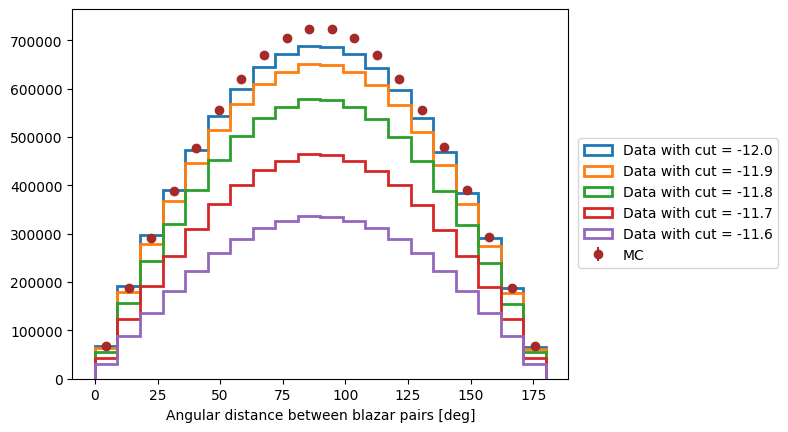

cut: -12.0, chi_sq: 276.06798926390974, pval: 0.0
cut: -11.9, chi_sq: 207.47556674588805, pval: 0.0
cut: -11.8, chi_sq: 99.0416035207588, pval: 1.868838417351526e-12
cut: -11.7, chi_sq: 42.04816706548356, pval: 0.002725883776501181
cut: -11.6, chi_sq: 10.588339832522006, pval: 0.9562077959840789


In [12]:
uniform_2d_test(name_cat="table-4LAC-DR2-h.fits")

cut_e: -12.0
cut_e: -11.9
cut_e: -11.8
cut_e: -11.7
cut_e: -11.6
0
10
20
30
40


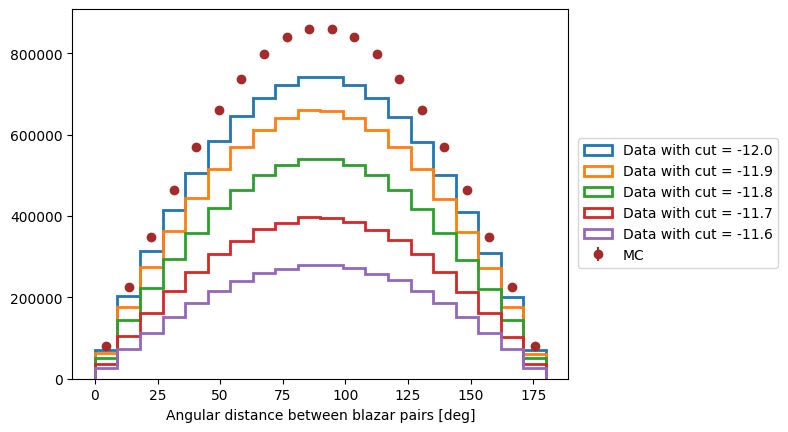

cut: -12.0, chi_sq: 174.51020639750857, pval: 0.0
cut: -11.9, chi_sq: 105.42562898399625, pval: 1.3300471835009375e-13
cut: -11.8, chi_sq: 30.49909602028906, pval: 0.06216013063843839
cut: -11.7, chi_sq: 17.504657309177333, pval: 0.6200027930846415
cut: -11.6, chi_sq: 33.13688228758031, pval: 0.03259179351156993


In [13]:
uniform_2d_test(name_cat="table-4LAC-DR3-h.fits")

cut_e: -12.0
cut_e: -11.9
cut_e: -11.8
cut_e: -11.7
cut_e: -11.6
0
10
20
30
40


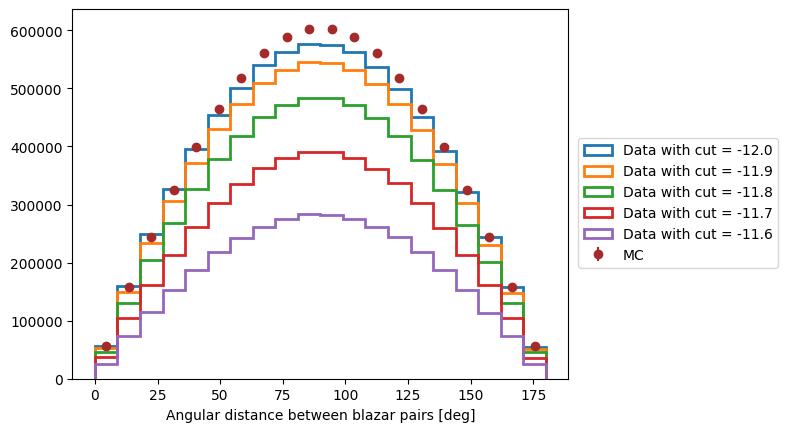

cut: -12.0, chi_sq: 271.71140806967486, pval: 0.0
cut: -11.9, chi_sq: 206.3524117008749, pval: 0.0
cut: -11.8, chi_sq: 108.0554205724561, pval: 4.440892098500626e-14
cut: -11.7, chi_sq: 47.553483174731156, pval: 0.0004912340750646838
cut: -11.6, chi_sq: 13.926867593362198, pval: 0.8341844677473653


In [14]:
uniform_2d_test()

In [15]:
help(np.asin)

Help on ufunc in module numpy:

arcsin = <ufunc 'arcsin'>
    arcsin(x, /, out=None, *, where=True, casting='same_kind', order='K', dtype=None, subok=True[, signature])

    Inverse sine, element-wise.

    Parameters
    ----------
    x : array_like
        `y`-coordinate on the unit circle.
    out : ndarray, None, or tuple of ndarray and None, optional
        A location into which the result is stored. If provided, it must have
        a shape that the inputs broadcast to. If not provided or None,
        a freshly-allocated array is returned. A tuple (possible only as a
        keyword argument) must have length equal to the number of outputs.
    where : array_like, optional
        This condition is broadcast over the input. At locations where the
        condition is True, the `out` array will be set to the ufunc result.
        Elsewhere, the `out` array will retain its original value.
        Note that if an uninitialized `out` array is created via the default
        ``out=

In [16]:
from astropy.coordinates import angular_separation

np.rad2deg(
    angular_separation(
        np.deg2rad(rnd_lat),
        np.deg2rad(rnd_lon),
        np.deg2rad(rnd_lat),
        np.deg2rad(rnd_lon),
    )
)

array([0., 0., 0., ..., 0., 0., 0.], shape=(3063,))

cut_e: -11.6


(array([0.00252293, 0.00259259, 0.00172464, 0.00327288, 0.00525651,
        0.00303589, 0.00182699, 0.00371653, 0.00253451, 0.00364979,
        0.0027114 , 0.00244403, 0.00254565, 0.00317106, 0.00208359,
        0.00195207, 0.0026186 , 0.00259666, 0.00226172, 0.00307331]),
 array([2.23831236e-01, 1.82122459e+01, 3.62006607e+01, 5.41890755e+01,
        7.21774902e+01, 9.01659088e+01, 1.08154320e+02, 1.26142731e+02,
        1.44131149e+02, 1.62119568e+02, 1.80107986e+02, 1.98096390e+02,
        2.16084808e+02, 2.34073227e+02, 2.52061630e+02, 2.70050079e+02,
        2.88038483e+02, 3.06026886e+02, 3.24015320e+02, 3.42003723e+02,
        3.59992157e+02]),
 [<matplotlib.patches.Polygon at 0x7f74220dbb60>])

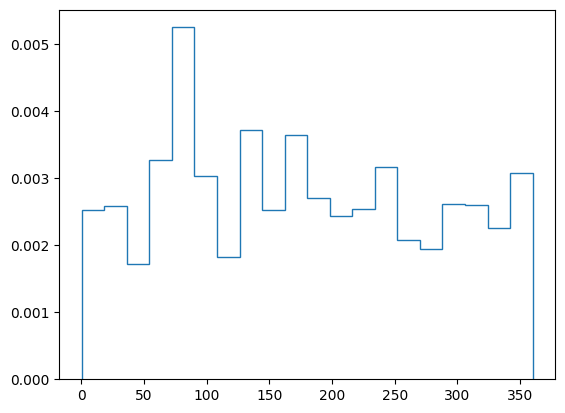

In [17]:
name_cat = "table_4LAC.fits"
alertstack_data_dir = "../../alertstack/data/"
with fits.open(os.path.join(alertstack_data_dir, name_cat)) as hdul:
    cat = hdul[1].data
    header = hdul[1].header
cat = np.sort(cat, order="Energy_Flux100")[::-1]

#blazar_class = ["bll", "BLL", "fsrq", "FSRQ", "bcu", "BCU"]
blazar_class = ["bll", "BLL", "fsrq", "FSRQ", "bcu", "BCU"]

mask = np.array([x["CLASS"] in blazar_class for x in cat])
blazars = np.array(cat[mask])

cut_e = -12. + 0.1*4
print(f"cut_e: {cut_e}")
mask_e = np.array([x["Energy_Flux100"]>10**cut_e for x in blazars])
blazars_cut = np.array(blazars[mask_e])

plt.hist(
    blazars_cut["GLON"],
    bins=20, histtype='step', density=True, weights=blazars_cut["Energy_Flux100"]
    #label=f"{cut_e} {round(pval,2):.2f}", linewidth=2,
)

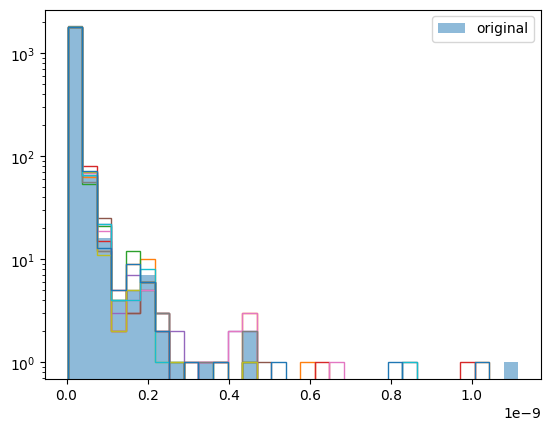

In [18]:
logbins = np.logspace(
    np.log10(np.min(blazars_cut["Energy_Flux100"])),
    np.log10(np.max(blazars_cut["Energy_Flux100"])),
    30
)
energyrange = (
    np.min(blazars_cut["Energy_Flux100"]),
    np.max(blazars_cut["Energy_Flux100"])
)
plt.hist(
    blazars_cut["Energy_Flux100"],
    bins=31,
    range=energyrange,
    alpha=0.5,
    label="original"
)

cdf = stats.ecdf(blazars_cut["Energy_Flux100"]).cdf
probs = cdf.probabilities[:-1] - cdf.probabilities[1:]

for i in range(10):
    plt.hist(
        stats.rv_histogram((probs, cdf.quantiles)).rvs(size=len(blazars_cut)),
        bins=31, histtype='step',
        range=energyrange
    )

#plt.xscale("log")
plt.yscale("log")
plt.legend()

In [19]:
means, stds, xs = weighted_means_stds(blazars_cut)

plt.errorbar(
    xs,
    means, stds, color = "red", marker='o',
    linestyle="",
)

NameError: name 'weighted_means_stds' is not defined

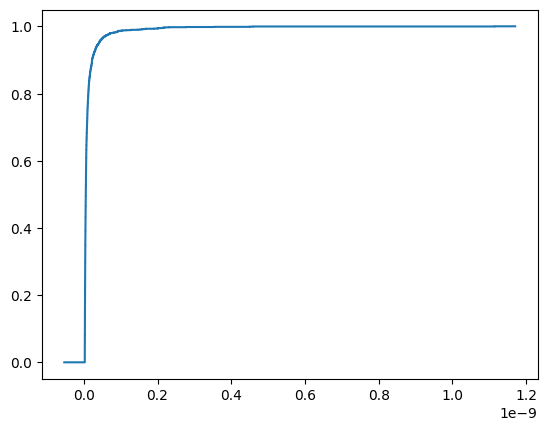

In [20]:
stats.ecdf(blazars_cut["Energy_Flux100"]).cdf.plot()

In [21]:
cdf = stats.ecdf(blazars_cut["Energy_Flux100"]).cdf
uniform.rvs()

np.float64(0.2707508436089172)

In [22]:
cdf.evaluate(0.1e-10)

array(0.7526096)

In [23]:
ecdf = stats.ecdf(blazars_cut["Energy_Flux100"])
ecdf.sf.evaluate(0.1e-10)

array(0.2473904)

In [24]:
probs = cdf.probabilities[:-1] - cdf.probabilities[1:]